In [187]:
!pip install ipykernel
!pip install scanpy
!pip install scvi-tools
!pip install --quiet scvi-colab
from scvi_colab import install

install()

Python(16326) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Defaulting to user installation because normal site-packages is not writeable


Python(16327) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Defaulting to user installation because normal site-packages is not writeable


Python(16328) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Defaulting to user installation because normal site-packages is not writeable


Python(16329) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
/Users/XXW004/Library/Python/3.13/lib/python/site-packages/scvi_colab/_core.py:46: UserWarning: 
                Not currently in Google Colab environment.

                Please run with `run_outside_colab=True` to override.

                Returning with no further action.
                
  warn(


In [188]:

import os
import tempfile

import scanpy as sc
import scvi
import seaborn as sns
import torch

scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

In [75]:
import scanpy as sc
# path to my datasets

adata_path = "/Users/XXW004/Documents/Projects/RuizRosado/PIPseq/Datasets/Reference_Published/MKA_MouseKidney/MouseKidneyATLAS_MKA_updated.h5ad"

# Load the reference dataset
adata_ref = sc.read_h5ad(adata_path)

# Check the object
print(adata_ref)
print(adata_ref.obs.head())  # cell metadata
print(adata_ref.var.head())  # gene metadata

AnnData object with n_obs × n_vars = 141401 × 16641
    obs: 'Origin', 'suspension_type', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'author_cell_type', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'cell_type_ontology_term_id', 'organism_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'development_stage_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'donor_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'schema_reference', 'schema_version', '

In [77]:
import mygene
import pandas as pd

mg = mygene.MyGeneInfo()
ens_ids = list(adata_ref.var_names)

# Query mapping
out = mg.querymany(
    ens_ids,
    scopes='ensembl.gene',
    fields='symbol',
    species='mouse'
)

# Build mapping with fallback
ens_to_symbol = {}
for d in out:
    query_id = d['query']
    symbol = d.get('symbol', query_id)  # fallback to original Ensembl ID
    ens_to_symbol[query_id] = symbol

# Rename var_names safely
adata_ref.var_names = [ens_to_symbol[x] for x in adata_ref.var_names]

# Optional: remove duplicates
adata_ref = adata_ref[:, ~adata_ref.var_names.duplicated()]
print(adata_ref.var.head())  # gene metadata


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
2 input query terms found dup hits:	[('ENSMUSG00000112376', 2), ('ENSMUSG00000072694', 2)]
68 input query terms found no hit:	['ENSMUSG00000098243', 'ENSMUSG00000100301', 'ENSMUSG00000103659', 'ENSMUSG00000104340', 'ENSMUSG000


         feature_is_filtered                 feature_name feature_reference  \
Serpinb8               False  Serpinb8_ENSMUSG00000026315   NCBITaxon:10090   
Aox1                   False      Aox1_ENSMUSG00000063558   NCBITaxon:10090   
Cnnm3                  False     Cnnm3_ENSMUSG00000001138   NCBITaxon:10090   
Lman2l                 False    Lman2l_ENSMUSG00000001143   NCBITaxon:10090   
Ankrd39                False   Ankrd39_ENSMUSG00000079610   NCBITaxon:10090   

         feature_biotype feature_length    feature_type  
Serpinb8            gene           2096  protein_coding  
Aox1                gene           5426  protein_coding  
Cnnm3               gene           1006  protein_coding  
Lman2l              gene           1843  protein_coding  
Ankrd39             gene           1276  protein_coding  


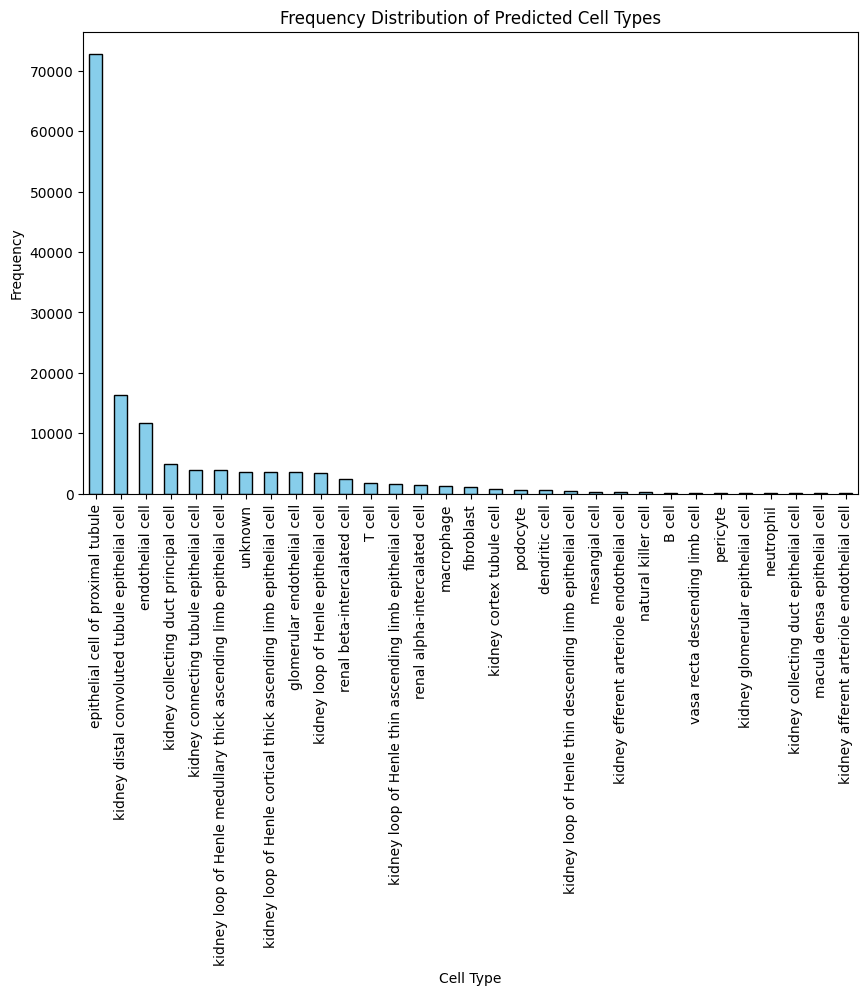

In [14]:
# Generate frequency distribution of cell types
cell_type_counts = adata_ref.obs['cell_type'].value_counts()

# Visualize the distribution using a bar plot
import matplotlib.pyplot as plt
cell_type_counts.plot(kind='bar', figsize=(10, 6), color='skyblue', edgecolor='black')
plt.title('Frequency Distribution of Predicted Cell Types', fontsize=16)
plt.title('Frequency Distribution of Predicted Cell Types')
plt.xlabel('Cell Type')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.show()

In [194]:


# load the query

Cisplatin_path = "/Users/XXW004/Documents/Projects/Diana_Zepedo_Orozco/scRNAseq_/Results/Annotation/Cisplatin_Vehicle_Raw_Predict_Annotation.h5ad"

# Load the dataset
adata_query = sc.read_h5ad(Cisplatin_path)

# Check the object
print(adata_query)
print(adata_query.obs.head())  # cell metadata
print(adata_query.var.head())  # gene metadata

AnnData object with n_obs × n_vars = 9898 × 21258
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'rDNA', 'DataSet', 'doublet_id', 'RNA_snn_res.1', 'seurat_clusters', 'predicted.id', 'prediction.score.endothelial.cell', 'prediction.score.kidney.loop.of.Henle.medullary.thick.ascending.limb.epithelial.cell', 'prediction.score.kidney.collecting.duct.principal.cell', 'prediction.score.epithelial.cell.of.proximal.tubule', 'prediction.score.kidney.distal.convoluted.tubule.epithelial.cell', 'prediction.score.fibroblast', 'prediction.score.kidney.loop.of.Henle.epithelial.cell', 'prediction.score.kidney.connecting.tubule.epithelial.cell', 'prediction.score.kidney.loop.of.Henle.cortical.thick.ascending.limb.epithelial.cell', 'prediction.score.pericyte', 'prediction.score.renal.alpha.intercalated.cell', 'prediction.score.macrophage', 'prediction.score.podocyte', 'prediction.score.renal.beta.intercalated.cell', 'prediction.score.kidney.cortex.tubule.cell', 'prediction.score.T.ce

In [79]:
# preprocess
shared_genes = adata_ref.var_names.intersection(adata_query.var_names)
print("Number of shared genes:", len(shared_genes))

#adata_ref = adata_ref[:, shared_genes].copy()
#adata_query = adata_query[:, shared_genes].copy()

Number of shared genes: 14765


# Step 3: Setup the AnnoData for scVI/ScANV

In [83]:
import scvi

# Make a writable copy
adata_ref_copy = adata_ref.copy()

# Check your label column
print(adata_ref_copy.obs['cell_type'].unique())

# Setup scVI
scvi.model.SCVI.setup_anndata(adata_ref_copy, labels_key='cell_type')
adata_query_copy = adata_query.copy()

['endothelial cell', 'kidney loop of Henle medullary thick ascendin..., 'kidney collecting duct principal cell', 'epithelial cell of proximal tubule', 'kidney distal convoluted tubule epithelial cell', ..., 'dendritic cell', 'vasa recta descending limb cell', 'kidney afferent arteriole endothelial cell', 'kidney efferent arteriole endothelial cell', 'mesangial cell']
Length: 31
Categories (31, object): ['B cell', 'T cell', 'dendritic cell', 'endothelial cell', ..., 'renal alpha-intercalated cell', 'renal beta-intercalated cell', 'unknown', 'vasa recta descending limb cell']


/Users/XXW004/Library/Python/3.13/lib/python/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


# Step 4: Train the model on reference

In [90]:
from scvi.model import SCVI

model = SCVI(adata_ref_copy)
model.train()


/Users/XXW004/Library/Python/3.13/lib/python/site-packages/scvi/train/_trainrunner.py:86: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/XXW004/Library/Python/3.13/lib/python/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/XXW004/Library/Python/3.13/lib/python/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(t

Epoch 1/57:   0%|          | 0/57 [00:00<?, ?it/s]

/Users/XXW004/Library/Python/3.13/lib/python/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/Users/XXW004/Library/Python/3.13/lib/python/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)


Epoch 2/57:   2%|▏         | 1/57 [01:15<1:10:14, 75.25s/it, v_num=1, train_loss=2.08e+3]

/Users/XXW004/Library/Python/3.13/lib/python/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/Users/XXW004/Library/Python/3.13/lib/python/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)


...

Epoch 57/57:  98%|█████████▊| 56/57 [1:07:45<01:09, 69.38s/it, v_num=1, train_loss=1.86e+3]

/Users/XXW004/Library/Python/3.13/lib/python/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/Users/XXW004/Library/Python/3.13/lib/python/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)


Epoch 57/57: 100%|██████████| 57/57 [1:08:55<00:00, 69.50s/it, v_num=1, train_loss=1.86e+3]

`Trainer.fit` stopped: `max_epochs=57` reached.


Epoch 57/57: 100%|██████████| 57/57 [1:08:55<00:00, 72.55s/it, v_num=1, train_loss=1.86e+3]


Now we obtain the latent representation, and use Scanpy to visualize with UMAP.

In [102]:
# saving and loading
save_dir = tempfile.TemporaryDirectory()
scvi_ref_path = os.path.join(save_dir.name, "scvi_model")
model.save(scvi_ref_path, overwrite=True)
scvi_ref_path


'/var/folders/42/8146lff94_bdjcvy1yrcbf0r0000gq/T/tmpg2ax72ks/scvi_model'

In [ ]:

# Obtaining model outputs#
SCVI_LATENT_KEY = "X_scVI"

adata_ref_copy.obsm[SCVI_LATENT_KEY] = scvi_ref.get_latent_representation()
sc.pp.neighbors(adata_ref_copy, use_rep=SCVI_LATENT_KEY)
sc.tl.leiden(adata_ref_copy)
sc.tl.umap(adata_ref_copy)

# Step 4. Update with query

In [116]:
# get reference genes
#ref_model = scvi.model.SCVI.load(scvi_ref_path)
ref_genes = adata_ref_copy.var_names

# subset your query AnnData to the same genes
adata_query_copy = adata_query_copy[:, ref_genes].copy()
# both are valid
scvi.model.SCVI.prepare_query_anndata(adata_query_copy, scvi_ref_path)
scvi.model.SCVI.prepare_query_anndata(adata_query_copy, model)



INFO     File /var/folders/42/8146lff94_bdjcvy1yrcbf0r0000gq/T/tmpg2ax72ks/scvi_model/model.pt already downloaded  
INFO     Found 100.0% reference vars in query data.                                                                
INFO     Found 100.0% reference vars in query data.                                                                


In [117]:
import pandas as pd

# create an empty cell_type column
adata_query_copy.obs['cell_type'] = pd.Categorical(['unknown'] * adata_query_copy.n_obs)
adata_query_copy.obs.head() 
adata_query_copy.obs.dtypes      # check data types


orig.ident                                                                              category
nCount_RNA                                                                               float64
nFeature_RNA                                                                               int32
percent.mt                                                                               float64
rDNA                                                                                     float64
DataSet                                                                                 category
doublet_id                                                                              category
RNA_snn_res.1                                                                           category
seurat_clusters                                                                         category
predicted.id                                                                            category
prediction.score.endothelial.c

In [135]:
adata_combined = adata_ref_copy.concatenate(
    adata_query_copy,
    batch_key='batch',               # adds 'batch' column: ref/query
    batch_categories=['ref','query'] # optional: label batches
)

/var/folders/42/8146lff94_bdjcvy1yrcbf0r0000gq/T/ipykernel_91176/3193081315.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_combined = adata_ref_copy.concatenate(
/Users/XXW004/Library/Python/3.13/lib/python/site-packages/anndata/_core/anndata.py:1762: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  out = concat(


In [137]:
# mark query cells as 'Unknown'
adata_query_copy.obs['cell_type'] = 'Unknown'
# merge reference + query
adata_combined = adata_ref_copy.concatenate(
    adata_query_copy,
    batch_key='batch',
    batch_categories=['ref', 'query']
)

print(adata_combined)


/var/folders/42/8146lff94_bdjcvy1yrcbf0r0000gq/T/ipykernel_91176/777593388.py:4: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_combined = adata_ref_copy.concatenate(
/Users/XXW004/Library/Python/3.13/lib/python/site-packages/anndata/_core/anndata.py:1762: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  out = concat(


AnnData object with n_obs × n_vars = 151299 × 16634
    obs: 'Origin', 'suspension_type', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'author_cell_type', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'cell_type_ontology_term_id', 'organism_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'development_stage_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'donor_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', '_scvi_batch', '_scvi_labels', 'cell_type_unknown', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'rDNA', 'DataSet', 'doublet_id', 'RNA_snn_res.1', 'seurat_clusters', '

In [139]:
# =========================
# 5️⃣ Setup SCANVI
# =========================
scvi.model.SCANVI.setup_anndata(
    adata_combined,
    labels_key='cell_type',
    batch_key='batch',
    unlabeled_category='Unknown'
)




/Users/XXW004/Library/Python/3.13/lib/python/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [141]:

# =========================
# 6️⃣ Train SCANVI model
# =========================
scanvi_model = scvi.model.SCANVI(
    adata_combined,
)

scanvi_model.train(max_epochs=50)  # adjust epochs as needed


INFO     Training for 50 epochs.                                                                                   


/Users/XXW004/Library/Python/3.13/lib/python/site-packages/scvi/train/_trainrunner.py:86: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/XXW004/Library/Python/3.13/lib/python/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/XXW004/Library/Python/3.13/lib/python/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(t

Epoch 1/50:   0%|          | 0/50 [00:00<?, ?it/s]

/Users/XXW004/Library/Python/3.13/lib/python/site-packages/scvi/module/_scanvae.py:223: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -px.log_prob(x).sum(-1)


Epoch 2/50:   2%|▏         | 1/50 [01:46<1:26:45, 106.23s/it, v_num=1, train_loss=2.06e+3]

...

Epoch 50/50:  98%|█████████▊| 49/50 [1:23:08<01:38, 98.95s/it, v_num=1, train_loss=1.82e+3]

/Users/XXW004/Library/Python/3.13/lib/python/site-packages/scvi/module/_scanvae.py:223: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -px.log_prob(x).sum(-1)


Epoch 50/50: 100%|██████████| 50/50 [1:24:45<00:00, 98.57s/it, v_num=1, train_loss=1.82e+3]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 50/50: 100%|██████████| 50/50 [1:24:45<00:00, 101.72s/it, v_num=1, train_loss=1.82e+3]


In [161]:
# Predict on query only
query_mask = adata_combined.obs["batch"] == "query"

query_preds = scanvi_model.predict(
    adata_combined[query_mask],
    soft=True
)
type(query_preds)



INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


pandas.core.frame.DataFrame

In [164]:
# print(type(query_preds))

label_names = scanvi_model.adata_manager.get_state_registry("labels")[
    "categorical_mapping"
]

print(label_names)



['B cell' 'T cell' 'vasa recta descending limb cell' 'dendritic cell'
 'endothelial cell' 'epithelial cell of proximal tubule' 'fibroblast'
 'glomerular endothelial cell'
 'kidney afferent arteriole endothelial cell'
 'kidney collecting duct epithelial cell'
 'kidney collecting duct principal cell'
 'kidney connecting tubule epithelial cell' 'kidney cortex tubule cell'
 'kidney distal convoluted tubule epithelial cell'
 'kidney efferent arteriole endothelial cell'
 'kidney glomerular epithelial cell'
 'kidney loop of Henle cortical thick ascending limb epithelial cell'
 'kidney loop of Henle epithelial cell'
 'kidney loop of Henle medullary thick ascending limb epithelial cell'
 'kidney loop of Henle thin ascending limb epithelial cell'
 'kidney loop of Henle thin descending limb epithelial cell' 'macrophage'
 'macula densa epithelial cell' 'mesangial cell' 'natural killer cell'
 'neutrophil' 'pericyte' 'podocyte' 'renal alpha-intercalated cell'
 'renal beta-intercalated cell' 'unknown

In [ ]:
prob_df = pd.DataFrame(
    query_preds,
    index=adata_combined.obs_names[query_mask],
    columns=label_names
)

pred_labels = prob_df.idxmax(axis=1)
pred_conf = prob_df.max(axis=1)

adata_combined.obs.loc[query_mask, "scanvi_label"] = pred_labels
adata_combined.obs.loc[query_mask, "scanvi_confidence"] = pred_conf
adata_combined.obs.loc[query_mask,
                       ["scanvi_label", "scanvi_confidence"]].head()

adata_combined.obs.loc[query_mask,].head()


,Origin,suspension_type,n_genes,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,...,prediction.score.kidney.efferent.arteriole.endothelial.cell,prediction.score.mesangial.cell,prediction.score.max,Sub1,Sub2,Raw_cell_type,ident,batch,scanvi_label,scanvi_confidence
AAAAAAAAACCTGTTG-query,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.459016,6_0,6_0,TAL,TAL,query,kidney loop of Henle cortical thick ascending ...,1.000000
AAAAAAAAACGTCCCC-query,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.994744,1,1,PT,PT,query,epithelial cell of proximal tubule,0.999989
AAAAAAAACGGAGCGC-query,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,1.000000,1,1,PT,PT,query,epithelial cell of proximal tubule,1.000000
AAAAAAAAGATCAGTG-query,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,1.000000,5,5,PT,PT,query,epithelial cell of proximal tubule,0.999999
AAAAAAAAGGTGATTG-query,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,1.000000,4,4,PT,PT,query,unknown,0.866391


In [175]:
# now I have get all the annotation meta data and I want to save it
query_meta = adata_combined.obs.loc[
    query_mask,
    ["predicted.id","prediction.score.max","Raw_cell_type","scanvi_label", "scanvi_confidence"]
].copy()




In [186]:
reference_mask = adata_combined.obs["batch"] == "ref"
refere_query_final = adata_combined[reference_mask].copy()

refere_query_final.write("reference_annotated_scanvi.h5ad")

OSError: Unable to synchronously create file (unable to truncate a file which is already open)

In [185]:

query_meta.to_csv("query_scanvi_manual_seurat_annotations.csv")
adata_query_final = adata_combined[query_mask].copy()

adata_query_final.write("query_annotated_scanvi.h5ad")



In [189]:
# read the h5d file for the query file

adata_query_final = sc.read_h5ad("query_annotated_scanvi.h5ad")



In [193]:
# check the object
adata_query_final.obs.head()


,Origin,suspension_type,n_genes,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,...,prediction.score.kidney.efferent.arteriole.endothelial.cell,prediction.score.mesangial.cell,prediction.score.max,Sub1,Sub2,Raw_cell_type,ident,batch,scanvi_label,scanvi_confidence
AAAAAAAAACCTGTTG-query,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.459016,6_0,6_0,TAL,TAL,query,kidney loop of Henle cortical thick ascending ...,1.000000
AAAAAAAAACGTCCCC-query,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.994744,1,1,PT,PT,query,epithelial cell of proximal tubule,0.999989
AAAAAAAACGGAGCGC-query,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,1.000000,1,1,PT,PT,query,epithelial cell of proximal tubule,1.000000
AAAAAAAAGATCAGTG-query,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,1.000000,5,5,PT,PT,query,epithelial cell of proximal tubule,0.999999
AAAAAAAAGGTGATTG-query,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,1.000000,4,4,PT,PT,query,unknown,0.866391


In [153]:
print(scanvi_model.adata_manager.summary_stats)
print(scanvi_model.adata_manager.get_state_registry("batch"))
# predict probabilities
#preds = scanvi_model.predict(adata_query_copy, soft=True)
#scanvi_model.predict(adata_query_copy, soft=True)  # get probabilities instead of hard labels

n_batch: 2
n_cells: 151299
n_extra_categorical_covs: 0
n_extra_continuous_covs: 0
n_labels: 32
n_vars: 16634

categorical_mapping: !!python/object/apply:numpy._core.multiarray._reconstruct
  args:
  - !!python/name:numpy.ndarray ''
  - !!python/tuple
    - 0
  - !!binary |
    Yg==
  state: !!python/tuple
  - 1
  - !!python/tuple
    - 2
  - !!python/object/apply:numpy.dtype
    args:
    - O8
    - false
    - true
    state: !!python/tuple
    - 3
    - '|'
    - null
    - null
    - null
    - -1
    - -1
    - 63
  - false
  - - ref
    - query
original_key: batch

